In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [ ]:
#-------Moount Google Drive------
from google.colab import drive
drive.mount('/content/GoogleDrive')


Drive already mounted at /content/GoogleDrive; to attempt to forcibly remount, call drive.mount("/content/GoogleDrive", force_remount=True).


In [ ]:
# Update to your folder path
data_dir = '/content/GoogleDrive/MyDrive/Food_Image'
train_path = os.path.join(data_dir, 'Train')
val_path = os.path.join(data_dir, 'Valid')
test_path = os.path.join(data_dir, 'Test')

In [ ]:
print(os.listdir(val_path))
print(os.listdir(train_path))
print(os.listdir(test_path))

['Fries', 'Burger', 'Crispy Chicken', 'Baked Potato', 'Hot Dog', 'Pizza']
['Crispy Chicken', 'Hot Dog', 'Pizza', 'Fries', 'Baked Potato', 'Burger']
['Fries', 'Baked Potato', 'Burger', 'Crispy Chicken', 'Hot Dog', 'Pizza']


In [ ]:
image_size = (150, 150)
batch_size = 72

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    val_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_data = val_test_gen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 9000 images belonging to 6 classes.
Found 1800 images belonging to 6 classes.
Found 600 images belonging to 6 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')  # 6 food classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop]
)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 553s 4s/step - accuracy: 0.1825 - loss: 1.9200 - val_accuracy: 0.2500 - val_loss: 1.7266
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 550s 4s/step - accuracy: 0.2962 - loss: 1.6928 - val_accuracy: 0.3911 - val_loss: 1.5324
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 548s 4s/step - accuracy: 0.4108 - loss: 1.5215 - val_accuracy: 0.4922 - val_loss: 1.3479
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 567s 4s/step - accuracy: 0.4728 - loss: 1.3690 - val_accuracy: 0.5550 - val_loss: 1.2247
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 560s 4s/step - accuracy: 0.5237 - loss: 1.2800 - val_accuracy: 0.5911 - val_loss: 1.1184
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 553s 4s/step - accuracy: 0.5679 - loss: 1.1556 - val_accuracy: 0.6022 - val_loss: 1.0855
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 560s 4s/step - accuracy: 0.6036 - loss: 1.0850 - val_accuracy: 0.6328 - val_loss: 1.0498
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 551s 4s/step - accuracy: 0.6361 - loss: 1.0037 - val_accu

In [ ]:
model.save("Food_imageCNNModel.keras")


In [ ]:
model.save("/content/GoogleDrive/MyDrive/Food_Image/Food_imageCNNModel.keras")


In [ ]:
#Save istory

# Convert history to DataFrame
history_df = pd.DataFrame(history.history)

# Save to CSV (optional)
history_df.to_csv("/content/GoogleDrive/MyDrive/Food_Image/training_historyRechecking.csv", index=False)

# Preview
history_df.head()


,accuracy,loss,val_accuracy,val_loss
0,0.204222,1.807921,0.250000,1.726629
1,0.318222,1.665719,0.391111,1.532448
2,0.424556,1.484205,0.492222,1.347862
3,0.495889,1.334329,0.555000,1.224703
4,0.536333,1.247408,0.591111,1.118425


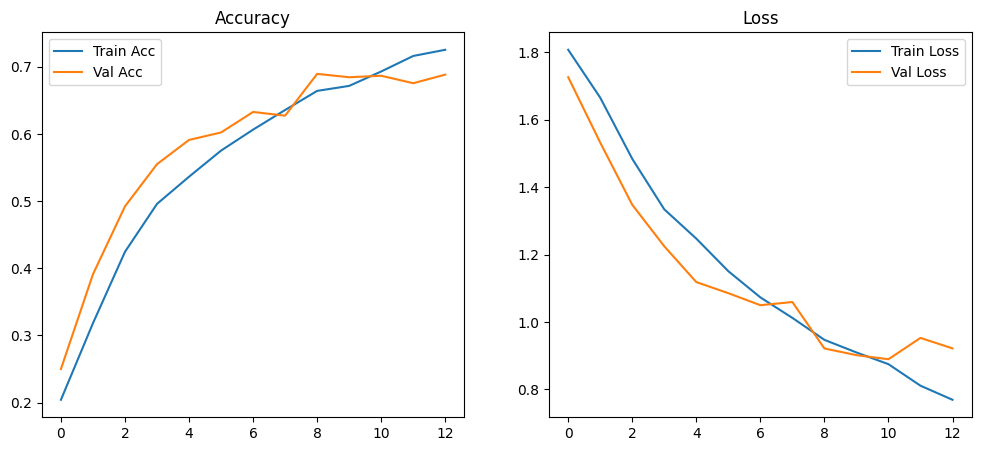

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 126s 16s/step
Classification Report:

                precision    recall  f1-score   support

  Baked Potato       0.72      0.83      0.77       100
        Burger       0.87      0.61      0.72       100
Crispy Chicken       0.59      0.91      0.71       100
         Fries       0.90      0.60      0.72       100
       Hot Dog       0.67      0.62      0.64       100
         Pizza       0.74      0.74      0.74       100

      accuracy                           0.72       600
     macro avg       0.75      0.72      0.72       600
  weighted avg       0.75      0.72      0.72       600



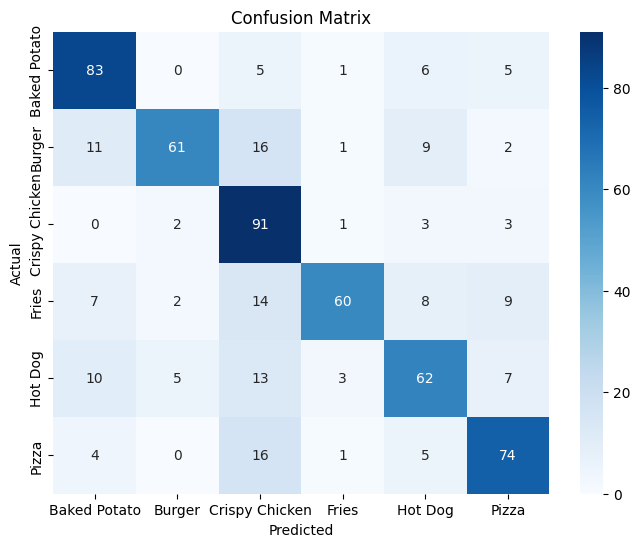

In [ ]:
# Predict test classes
pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Classification Report
print("Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


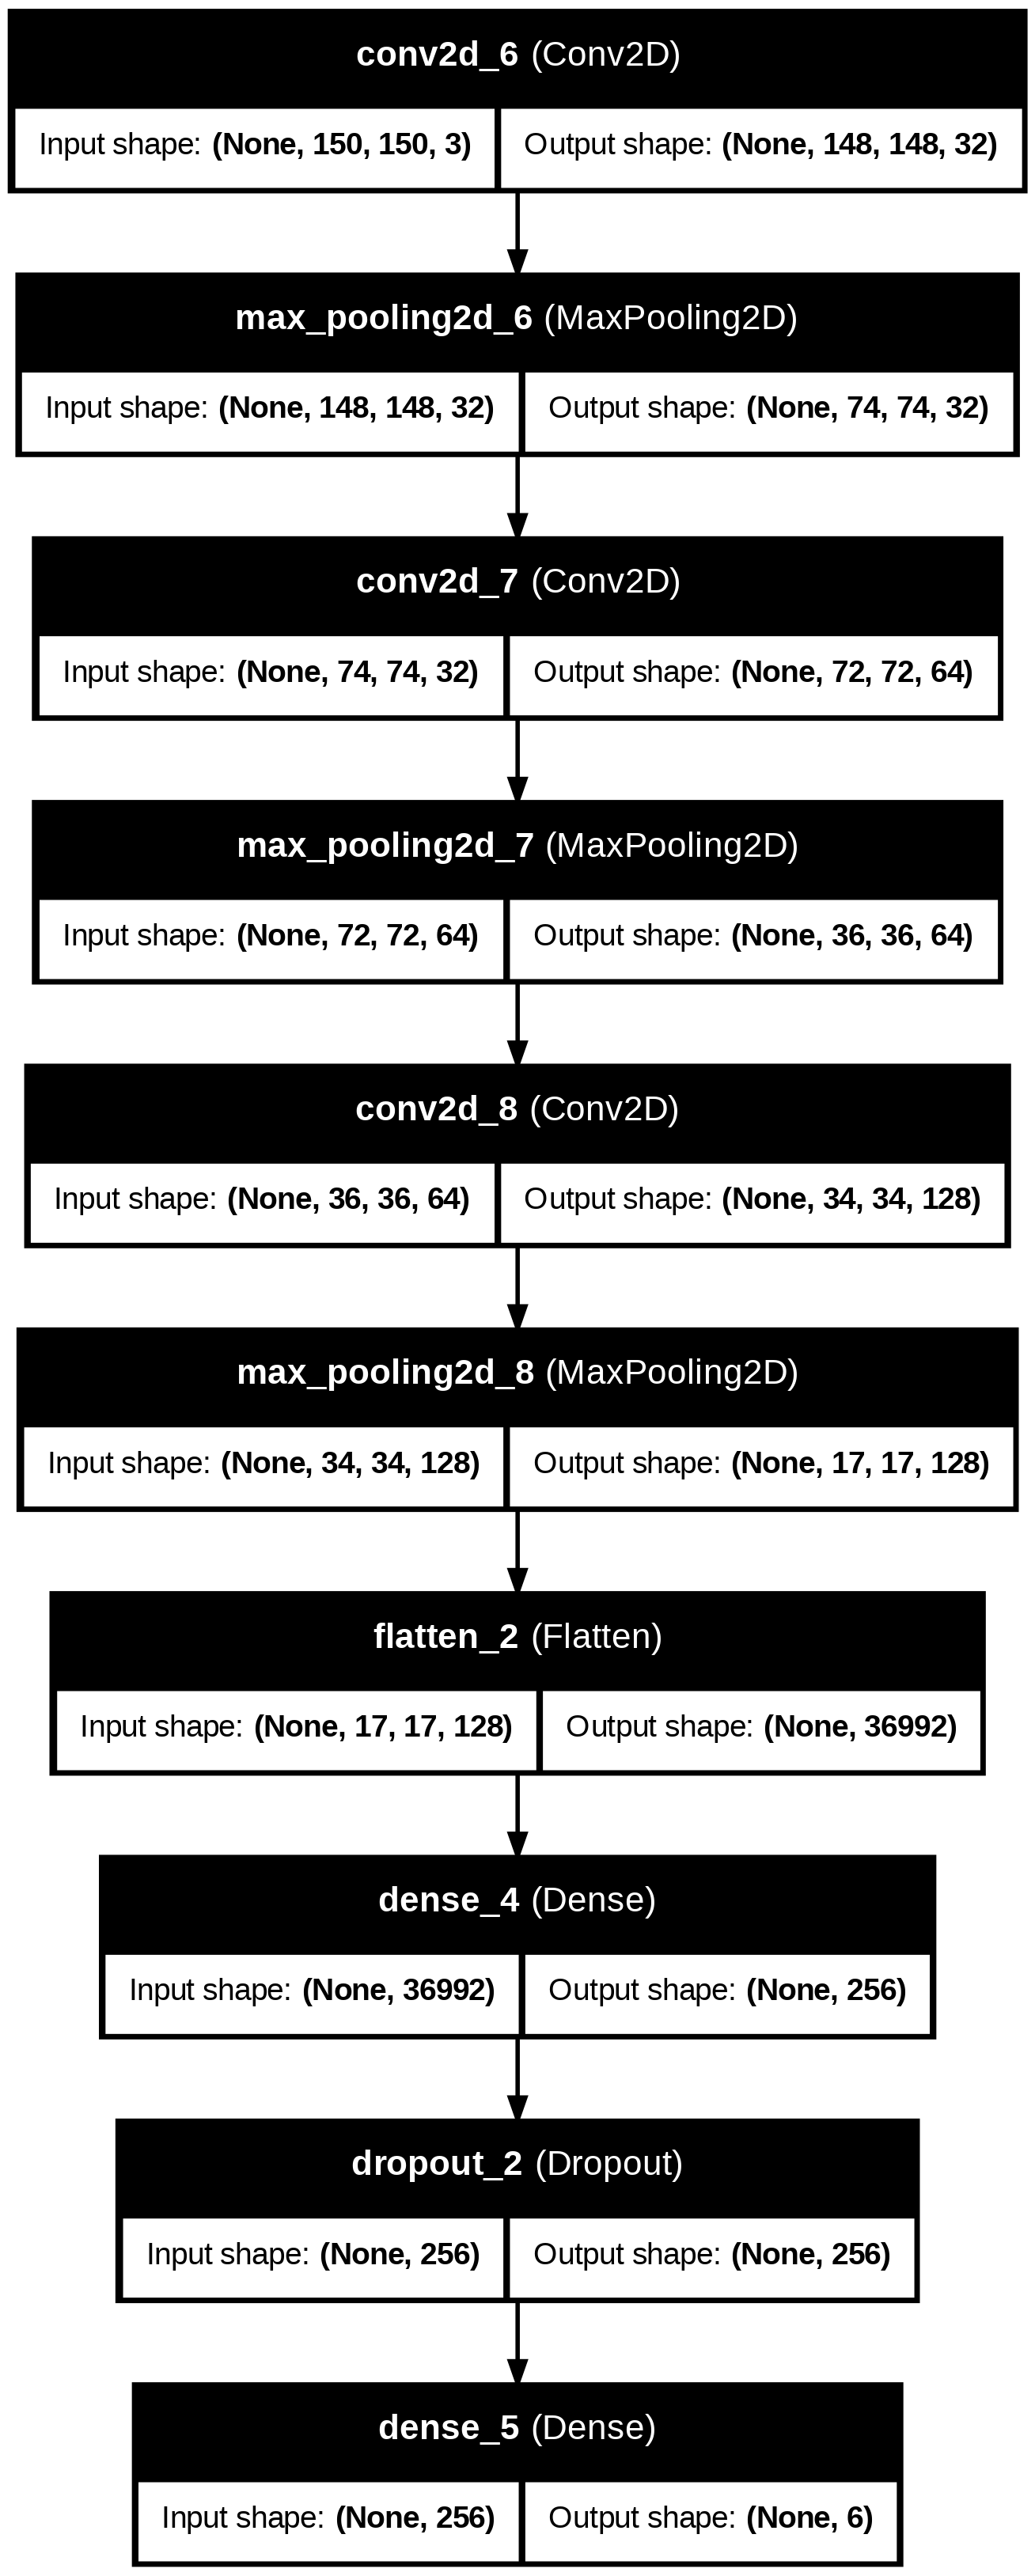

In [ ]:
from tensorflow.keras.utils import plot_model

# Save as PNG
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True)
